<h1> Entendendo os modos normais do ZnO</h1>


<div align="center">

| Zona de Brilloun Wurtzita (b) |
|:-:|
| ![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR7LcVS-TWvxd-_g5vkOqOgAzr3AgIUBQT93g&s) |

</div>

|       Qualquer lugar                   |         Centro da Zona           |
|:--------------------------------------:|:--------------------------------:|
| ![](../gallery/Phonon_modes.png) | ![](../gallery/Phonon_modes_Gamma.png) | 

In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:

def read_bands(filename: str):
    """Lê o arquivo .bands do alamode

    Returns:
        - labels1 : list[str]   com pontos de alta simetria -> xtick labels
        - pontos  : list[float] com pontos de alta simetria -> xticks  
        - x       : list[float] com pontos da Zona de Brillouin (qi_s)
        - bands   : list[float] com as frequências em Hz
    """
    with open(filename, "r") as f:
        lines: list[str] = f.readlines()

    labels: list[str] = lines[0].strip().split()[1:]
    labels_fmt = [r"$\Gamma$" if label == "G" else label for label in labels]

    points = np.array(lines[1].strip().split()[1:], dtype=float)

    data = np.loadtxt(filename, comments="#")
    x = data[:, 0]
    bands = data[:, 1:]

    return labels_fmt, points, x, bands



In [1]:
def map_zno_bands(band_array):
    """
    Mapeia um array (X, 12) para os modos específicos do ZnO.
    Assume que as bandas estão em ordem crescente de energia.
    """
    return {
        "Acusticos": band_array[:, 0:3],   # Transversal e Longitudinal Acústico
        "E2_low":    band_array[:, 3:5],   # Vibração Zn (Plano xy)
        "B1_low":    band_array[:, 5],     # Silencioso (Eixo z)
        "TO_modes":  band_array[:, 6:8],   # E1(TO) e A1(TO)
        "B1_high":   band_array[:, 8],     # Silencioso (Eixo z)
        "E2_high":   band_array[:, 9:11],  # Vibração O (Plano xy)
        "LO_top":    band_array[:, 11]     # Geralmente A1(LO)
    }


def plot_in_ax(x, y, ax, **kwargs):
    """Plot in a specified ax with optional keyword arguments color and linestyle"""
    

    ax.plot(x, y, **kwargs)

<details>

<summary> Código python </summary>

```python
style_DFT = dict(color="black", label="DFT")
style_MLFF = dict(color="gray", ls="--",label="MLFF")

fig, axes = plt.subplots(figsize=(10,10), ncols=3, nrows=5, layout="constrained", dpi=600)
fig.suptitle("Modos Normais Óxido de Zinco", size=18)


for ax in axes.flatten():
    ax.set_xticks(points1)
    ax.set_xticklabels(formatted_labels)

for i, ax in enumerate(axes.flatten()[:3]):
    ax.set_title(f"Acústico {i + 1}")
    plot_in_ax(x1, bandas_DFT["Acusticos"][:, i], ax=ax, **style_DFT)
    plot_in_ax(x1, bandas_MLFF["Acusticos"][:, i], ax=ax, **style_MLFF)


axes[1, 0].set_title(r"$E_2^{ \text{low} }$")
plot_in_ax(x1, bandas_DFT["E2_low"][:, 0], ax=axes[1, 0], **style_DFT)
plot_in_ax(x1, bandas_MLFF["E2_low"][:, 0], ax=axes[1, 0], **style_MLFF)

axes[1, 1].set_title(r"$E_2^{ \text{low} }$")
plot_in_ax(x1, bandas_DFT["E2_low"][:, 1], ax=axes[1, 1], **style_DFT)
plot_in_ax(x1, bandas_MLFF["E2_low"][:, 1], ax=axes[1, 1], **style_MLFF)

axes[1, 2].set_title(r"$B_1^{ \text{low} }$")
plot_in_ax(x1, bandas_DFT["B1_low"], ax=axes[1, 2], **style_DFT)
plot_in_ax(x1, bandas_MLFF["B1_low"], ax=axes[1, 2], **style_MLFF)


axes[2, 0].set_title(r"$TO_{ \text{modes} }$")
plot_in_ax(x1, bandas_DFT["TO_modes"][:, 0], ax=axes[2, 0], **style_DFT)
plot_in_ax(x1, bandas_MLFF["TO_modes"][:, 0], ax=axes[2, 0], **style_MLFF)

axes[2, 1].set_title(r"$TO_{ \text{modes} }$")
plot_in_ax(x1, bandas_DFT["TO_modes"][:, 1], ax=axes[2, 1], **style_DFT)
plot_in_ax(x1, bandas_MLFF["TO_modes"][:, 1], ax=axes[2, 1], **style_MLFF)


axes[2, 2].set_axis_off()

axes[3, 0].set_title(r"$B_1^{ \text{high} }$")
plot_in_ax(x1, bandas_DFT["B1_high"], ax=axes[3, 0], **style_DFT)
plot_in_ax(x1, bandas_MLFF["B1_high"], ax=axes[3, 0], **style_MLFF)



axes[3, 1].set_title(r"$E_2^{ \text{high} }$")
plot_in_ax(x1, bandas_DFT["E2_high"][:, 0], ax=axes[3, 1], **style_DFT)
plot_in_ax(x1, bandas_MLFF["E2_high"][:, 0], ax=axes[3, 1], **style_MLFF)

axes[3, 2].set_title(r"$E_2^{ \text{high} }$")
plot_in_ax(x1, bandas_DFT["E2_high"][:, 1], ax=axes[3, 2], **style_DFT)
plot_in_ax(x1, bandas_MLFF["E2_high"][:, 1], ax=axes[3, 2], **style_MLFF)

axes[4, 0].set_title(r"LO$_{ \text{top} }$")
plot_in_ax(x1, bandas_DFT["LO_top"], ax=axes[4, 0], **style_DFT)
plot_in_ax(x1, bandas_MLFF["LO_top"], ax=axes[4, 0], **style_MLFF)


axes[4, 1].set_axis_off()
axes[4, 2].set_axis_off()

handles, labels = axes[4, 0].get_legend_handles_labels()
fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0.8, 0.1), ncols=2)
fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0.95, 0.5), ncols=2)
plt.show()
```


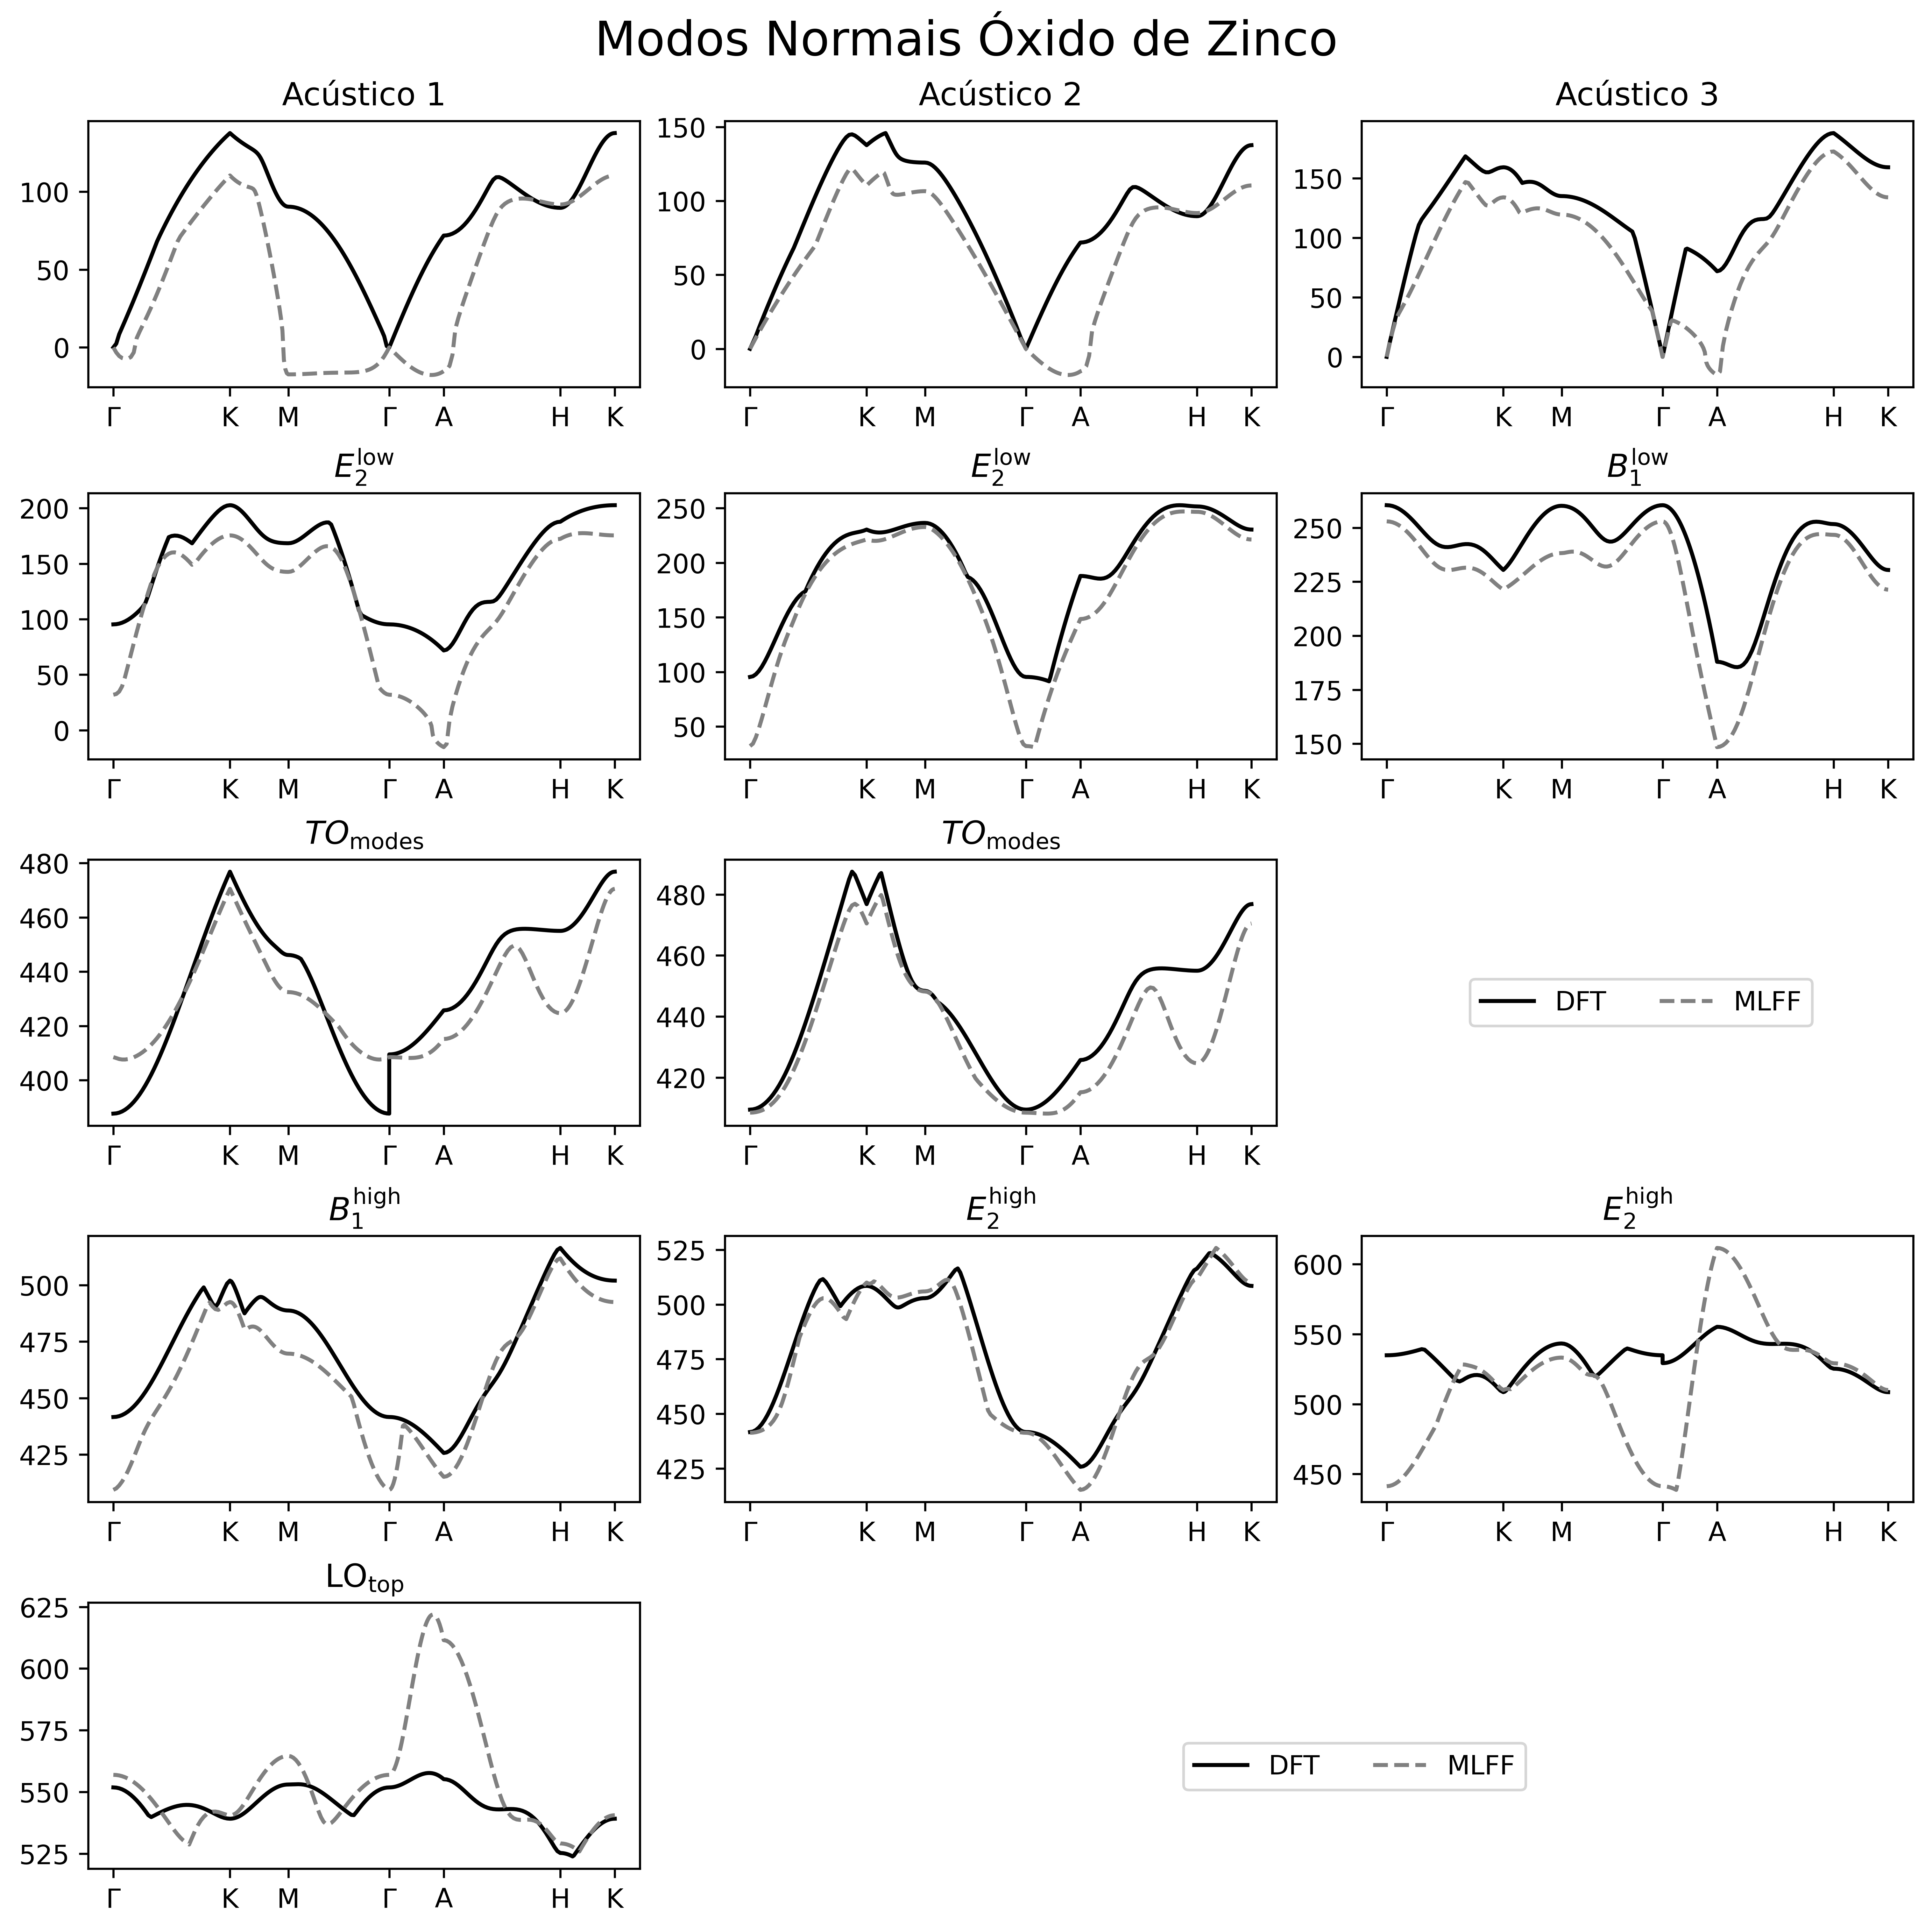

</details>